# Model Complexity

| Aspect                               | Underfitting (High Bias)                                                                                                                | Overfitting (High Variance)                                                                                                                               | Optimal Fit (Balanced Bias-Variance)                                                                                 |
| ------------------------------------ | --------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------- |
| **Definition**                       | Model too simple; fails to capture underlying patterns in data.                                                                         | Model too complex; captures noise and outliers as if they were real patterns.                                                                             | Model captures true patterns without fitting noise; generalizes well.                                                |
| **Bias Level**                       | High (systematic error; assumptions too strong)                                                                                         | Low (flexible; fits training data closely)                                                                                                                | Moderate (balanced assumptions)                                                                                      |
| **Variance Level**                   | Low (consistent but wrong predictions across datasets)                                                                                  | High (predictions change drastically with different training data)                                                                                        | Moderate (stable across datasets)                                                                                    |
| **Model Complexity**                 | Low (e.g., linear model on nonlinear data)                                                                                              | High (e.g., very deep tree or high-degree polynomial)                                                                                                     | Appropriate (matches data complexity)                                                                                |
| **Training Error**                   | High                                                                                                                                    | Very low (often near zero)                                                                                                                                | Low (but not excessively minimized)                                                                                  |
| **Validation/Test Error**            | High (similar to training error)                                                                                                        | High (much higher than training error)                                                                                                                    | Low (close to training error)                                                                                        |
| **Train-Val Error Gap**              | Small (both errors high and close)                                                                                                      | Large (train low, val high; gap widens)                                                                                                                   | Small to moderate (both low and converging)                                                                          |
| **Generalization Ability**           | Poor (fails on both train and new data)                                                                                                 | Poor (fails on new data despite excelling on train)                                                                                                       | Excellent (performs well on unseen data)                                                                             |
| **Performance on Training Data**     | Poor                                                                                                                                    | Excellent (memorizes data)                                                                                                                                | Good                                                                                                                 |
| **Performance on Unseen Data**       | Poor                                                                                                                                    | Poor                                                                                                                                                      | Good                                                                                                                 |
| **Bias-Variance Decomposition**      | Dominated by high Bias²; low Variance                                                                                                   | Dominated by high Variance; low Bias²                                                                                                                     | Minimized total error (Bias² + Variance)                                                                             |
| **Learning Curve Characteristics**   | Both train/val curves plateau at high error; little improvement with more data                                                          | Train error low and flat; val error high and may decrease slowly with more data                                                                           | Both curves converge to low error; adding data reduces gap                                                           |
| **Model Complexity vs. Error Curve** | High error at low complexity; test error decreases initially but remains high                                                           | Test error decreases then increases (U-shape); minimum at high complexity                                                                                 | Test error minimized at moderate complexity                                                                          |
| **Common Causes**                    | Too simple algorithm, insufficient features, excessive regularization, under-training, poor feature engineering                         | Too complex algorithm, small dataset, lack of regularization, too many features, noisy labels                                                             | Proper hyperparameter tuning, sufficient quality data, balanced regularization                                       |
| **Symptoms/Indicators**              | Poor metrics on train and val; model seems "dumb" or overly simplistic                                                                  | Excellent train metrics but drops sharply on val/holdout; sensitive to small data changes                                                                 | Consistent strong metrics across train, val, and cross-validation folds                                              |
| **Detection Methods**                | High train/val error, flat learning curves, bias-variance analysis, cross-validation                                                    | Large train-val gap, high variance in CV scores, validation curve shows peak then rise                                                                    | Low errors, converging learning curves, stable CV scores                                                             |
| **Remedies**                         | Increase complexity (e.g., deeper networks, polynomials), add features, reduce regularization, train longer, better feature engineering | Add more data, regularization (L1/L2, dropout), early stopping, ensemble methods, feature selection/pruning, cross-validation                             | Fine-tune (grid/random search, Bayesian optimization), monitor validation, use ensembles                             |
| **Impact of More Training Data**     | Limited improvement (error plateaus high)                                                                                               | Significant improvement (reduces variance; gap narrows)                                                                                                   | Continued improvement until irreducible error                                                                        |
| **Impact of Regularization**         | May worsen (already too constrained)                                                                                                    | Strong improvement (controls complexity)                                                                                                                  | Fine-tuning optimizes performance                                                                                    |
| **Typical Algorithm Examples**       | Linear regression on nonlinear data, shallow tree, excessive pruning                                                                    | Unpruned decision tree, very deep NN without dropout, kNN with low k                                                                                      | Well-tuned random forest, regularized SVM, dropout-enabled NN                                                        |
| **Implications**                     | Model fails business KPIs from day one; low ROI; easy to interpret but useless; quick to deploy but frequent full retraining needed     | High initial accuracy in pilot; crashes in production due to drift/new patterns; expensive monitoring/retraining; compliance risks (unstable predictions) | Reliable ROI; stable in production; easier MLOps (less drift handling); supports A/B testing and incremental updates |
| **Interpretability**                 | High (simple model)                                                                                                                     | Low (complex; black-box)                                                                                                                                  | Moderate to high (with techniques like SHAP on ensembles)                                                            |
| **Risks on PROD**                    | Systematic errors (e.g., always underpredicts risk in fraud detection)                                                                  | Erratic predictions on edge cases; poor handling of distribution shift                                                                                    | Robust to moderate shifts; maintainable long-term                                                                    |


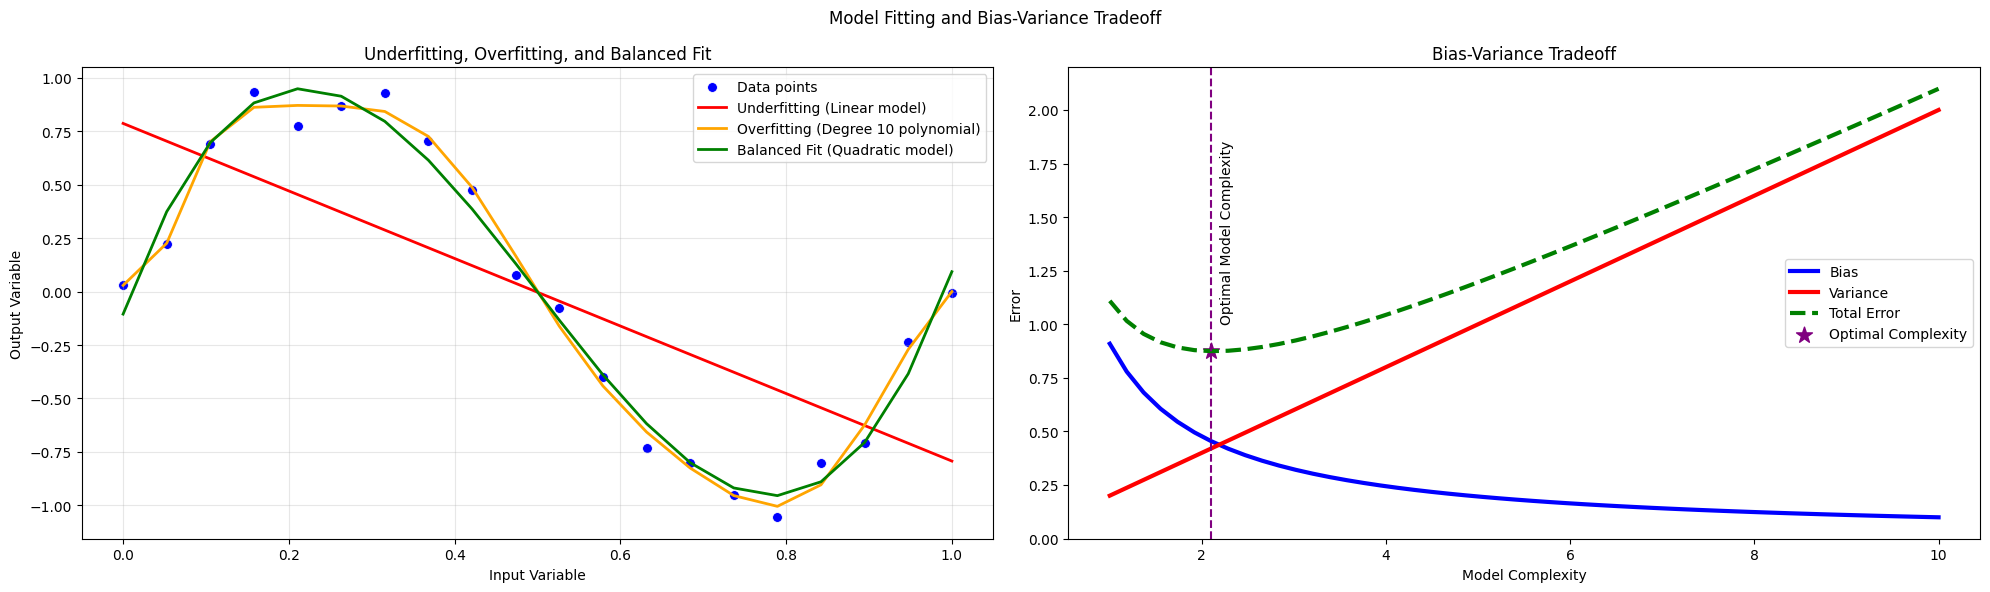

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

rng = np.random.default_rng(42)
X = np.linspace(0, 1, 20)
y = np.sin(2 * np.pi * X) + rng.normal(0, 0.1, 20)

coeffs_uf = np.polyfit(X, y, 1)
y_fit_uf = np.polyval(coeffs_uf, X)

coeffs_bf = np.polyfit(X, y, 3)
y_fit_bf = np.polyval(coeffs_bf, X)

coeffs_of = np.polyfit(X, y, 10)
y_fit_of = np.polyval(coeffs_of, X)

sns.scatterplot(x=X, y=y, s=50, color="blue", label="Data points", ax=axes[0])

sns.lineplot(
    x=X,
    y=y_fit_uf,
    color="red",
    linewidth=2,
    label="Underfitting (Linear model)",
    ax=axes[0],
)

sns.lineplot(
    x=X,
    y=y_fit_of,
    color="orange",
    linewidth=2,
    label="Overfitting (Degree 10 polynomial)",
    ax=axes[0],
)

sns.lineplot(
    x=X,
    y=y_fit_bf,
    color="green",
    linewidth=2,
    label="Balanced Fit (Quadratic model)",
    ax=axes[0],
)

axes[0].set_title("Underfitting, Overfitting, and Balanced Fit")
axes[0].set_xlabel("Input Variable")
axes[0].set_ylabel("Output Variable")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bias-Variance Tradeoff
model_complexity = np.linspace(1, 10, 50)
bias = 1 / (model_complexity + 0.1)
variance = model_complexity / 5
total_error = bias + variance

axes[1].plot(model_complexity, bias, "b-", linewidth=3, label="Bias")
axes[1].plot(model_complexity, variance, "r-", linewidth=3, label="Variance")
axes[1].plot(model_complexity, total_error, "g--", linewidth=3, label="Total Error")

optimal_idx = np.argmin(total_error)
optimal_complexity = model_complexity[optimal_idx]

axes[1].scatter(
    optimal_complexity,
    total_error[optimal_idx],
    color="purple",
    s=144,
    marker="*",
    label="Optimal Complexity",
)

axes[1].set_title("Bias-Variance Tradeoff")
axes[1].set_xlabel("Model Complexity")
axes[1].set_ylabel("Error")
axes[1].legend()

axes[1].axvline(x=optimal_complexity, color="purple", linestyle="--")
axes[1].text(
    optimal_complexity + 0.1,
    1,
    "Optimal Model Complexity",
    rotation=90,
    verticalalignment="bottom",
)

plt.suptitle("Model Fitting and Bias-Variance Tradeoff")
plt.tight_layout()
plt.show()


# Bias-Variance

- **Bias**: error due to overly simplistic assumptions in the model. High bias means the model is too simple and misses patterns in the data (underfitting).
- **Variance**: error due to sensitivity to small changes in the training data. High variance means the model is too complex and fits noise instead of true patterns (overfitting).


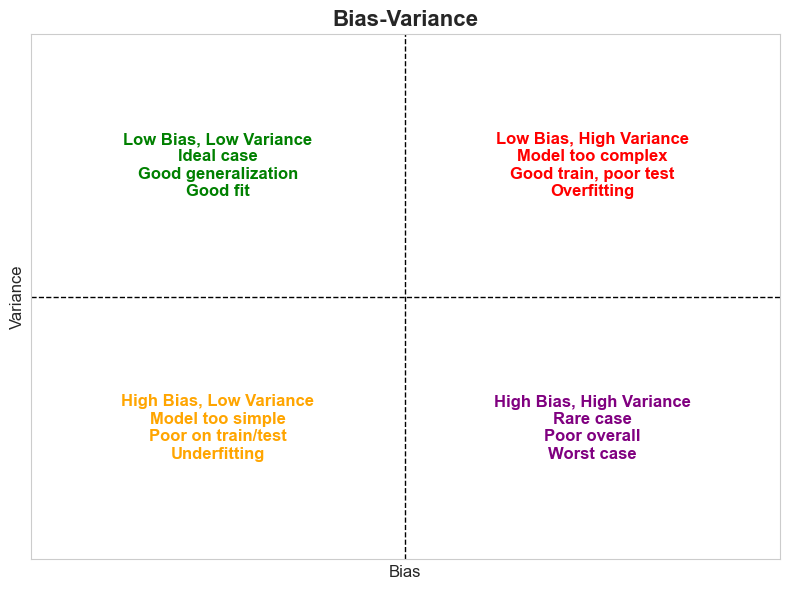

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 6))

ax.axhline(y=0.5, color="black", linestyle="--", linewidth=1)
ax.axvline(x=0.5, color="black", linestyle="--", linewidth=1)

ax.text(
    0.25,
    0.75,
    "Low Bias, Low Variance\nIdeal case\nGood generalization\nGood fit",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="green",
)
ax.text(
    0.75,
    0.75,
    "Low Bias, High Variance\nModel too complex\nGood train, poor test\nOverfitting",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="red",
)
ax.text(
    0.25,
    0.25,
    "High Bias, Low Variance\nModel too simple\nPoor on train/test\nUnderfitting",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="orange",
)
ax.text(
    0.75,
    0.25,
    "High Bias, High Variance\nRare case\nPoor overall\nWorst case",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="purple",
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Bias", fontsize=12)
ax.set_ylabel("Variance", fontsize=12)
ax.set_title("Bias-Variance", fontsize=16, fontweight="bold")

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()


## Bias-Variance Tradeoff

| Aspect                                        | High Bias / Low Variance (Underfitting)                                                                                                                                                                                    | Low Bias / High Variance (Overfitting)                                                                                                                                                                                                   | Optimal Balance (Good Generalization)                                                                                                                                                                                       |
| --------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Definition**                                | Error due to overly simplistic assumptions in the model. The model cannot capture the true underlying patterns in the data. Makes strong assumptions about data structure                                                  | Error due to excessive sensitivity to fluctuations in the training data. The model captures noise as if it were signal. Makes minimal assumptions about data structure                                                                   | Model complexity is tuned such that both bias and variance are reasonably low, minimizing total expected error                                                                                                              |
| **Assumptions About Data**                    | Strong assumptions about the form of the data distribution (e.g., linearity in linear regression, specific patterns). Oversimplifies relationships                                                                         | Weak or no strong assumptions; highly flexible and adaptable to complex, nonlinear, or varied data structures without presuming a specific form                                                                                          | Assumptions appropriately matched to the true complexity of the data; neither overly restrictive nor excessively permissive                                                                                                 |
| **Mathematical Role in Error Decomposition**  | High Bias² term dominates the reducible error. Total expected error = Bias² + Variance + Irreducible Error                                                                                                                 | High Variance term dominates the reducible error. Bias² is low, but Variance inflates total error                                                                                                                                        | Both Bias² and Variance are minimized simultaneously (as much as possible), yielding lowest total expected error                                                                                                            |
| **Model Complexity**                          | Too low (e.g., linear model on nonlinear data, insufficient features, excessive regularization)                                                                                                                            | Too high (e.g., very deep trees, high-degree polynomials, too many features, insufficient regularization)                                                                                                                                | Appropriate complexity matched to the true signal complexity and data volume                                                                                                                                                |
| **Flexibility**                               | Low flexibility; rigid structure limits adaptation to complex patterns                                                                                                                                                     | High flexibility; can model intricate, nonlinear, and nuanced relationships effectively                                                                                                                                                  | Balanced flexibility that captures true patterns without fitting noise                                                                                                                                                      |
| **Sensitivity to Training Data Fluctuations** | Low sensitivity; stable and consistent predictions across different training subsets or small changes (low variance)                                                                                                       | High sensitivity; predictions vary significantly with changes in training data or noise (high variance)                                                                                                                                  | Moderate sensitivity; stable yet adaptive to meaningful patterns                                                                                                                                                            |
| **Training Error**                            | High (model fails to fit even the training data well)                                                                                                                                                                      | Very low (model fits training data almost perfectly, including noise)                                                                                                                                                                    | Moderately low (fits training data well without memorizing noise)                                                                                                                                                           |
| **Validation/Test Error**                     | High (similar to training error; poor generalization due to systematic errors)                                                                                                                                             | Much higher than training error (large generalization gap)                                                                                                                                                                               | Close to training error and low overall (good generalization)                                                                                                                                                               |
| **Generalization Performance**                | Poor – systematic errors on both seen and unseen data                                                                                                                                                                      | Poor – performs well on training data but fails on new data due to noise fitting                                                                                                                                                         | Strong – performs well on both training and unseen data                                                                                                                                                                     |
| **Propensity to Underfit**                    | High risk of underfitting (misses important trends due to oversimplification)                                                                                                                                              | Low risk of underfitting (captures complex relationships well)                                                                                                                                                                           | Low risk of underfitting                                                                                                                                                                                                    |
| **Propensity to Overfit**                     | Low risk of overfitting (too simple to memorize noise)                                                                                                                                                                     | High risk of overfitting (captures noise as signal)                                                                                                                                                                                      | Low risk of overfitting                                                                                                                                                                                                     |
| **Learning Curve Behavior**                   | Training and validation error both high and converge to similar high values. No large gap                                                                                                                                  | Training error continues to decrease with more data, validation error high with large gap                                                                                                                                                | Both training and validation error decrease and converge to low values as data increases                                                                                                                                    |
| **Bias-Variance Characteristics**             | High bias, low variance (predictions stable but consistently wrong)                                                                                                                                                        | Low bias, high variance (predictions flexible but highly sensitive to training set changes)                                                                                                                                              | Low bias, low variance (accurate and stable predictions)                                                                                                                                                                    |
| **Typical Causes**                            | - Insufficient model capacity<br>- Excessive regularization (e.g., high λ in ridge)<br>- Poor feature engineering<br>- Too few parameters<br>- Early stopping too soon<br>- Strong data assumptions                        | - Excessive model capacity<br>- Insufficient regularization<br>- Too many parameters/features<br>- Training too long<br>- Small training dataset<br>- Minimal data assumptions                                                           | - Proper regularization strength<br>- Adequate data volume<br>- Cross-validation for hyperparameter tuning<br>- Ensemble methods<br>- Balanced assumptions                                                                  |
| **Common Model Examples**                     | - Linear regression on highly nonlinear data<br>- Shallow decision tree<br>- Logistic regression on complex patterns<br>- Strong L1/L2 regularization<br>- Simple parametric models with strong distributional assumptions | - Very deep/unpruned decision tree<br>- High-degree polynomial regression<br>- Deep neural net on small data<br>- k-NN with k=1<br>- Random Forests without constraints<br>- Complex neural networks                                     | - Decision tree with appropriate depth/pruning<br>- Random Forest with tuning<br>- Neural net with dropout/regularization<br>- SVM with tuned kernel<br>- Well-regularized models                                           |
| **Interpretability**                          | Generally high (simpler structure makes relationships easier to understand)                                                                                                                                                | Generally low (complex structure reduces transparency and explainability)                                                                                                                                                                | Varies; often improved with techniques like feature importance, SHAP, or simpler ensembles                                                                                                                                  |
| **Computational Efficiency**                  | High efficiency (fewer parameters, faster training/inference)                                                                                                                                                              | Lower efficiency (more parameters, higher training time and resource demands)                                                                                                                                                            | Moderate efficiency (balanced complexity for performance vs. cost)                                                                                                                                                          |
| **Diagnosis Techniques**                      | - High training error<br>- Learning curves show high error plateau<br>- Validation error ≈ training error<br>- Residual plots show systematic patterns<br>- Cross-validation scores consistently poor                      | - Large gap between training and validation error<br>- Validation error increases after a point<br>- Model performance varies greatly with different train/val splits<br>- High influence of individual points                           | - Small gap between training and validation error<br>- Validation error at minimum<br>- Stable performance across folds/splits<br>- Learning curves converge low                                                            |
| **Mitigation Strategies**                     | - Increase model complexity (more layers, higher degree)<br>- Add better/more features<br>- Reduce regularization strength<br>- Use more sophisticated algorithms<br>- Train longer<br>- Relax strong assumptions          | - Increase training data<br>- Apply stronger regularization (L1/L2, dropout)<br>- Reduce model complexity (pruning, fewer features)<br>- Early stopping<br>- Data augmentation<br>- Cross-validation<br>- Add constraints to flexibility | - Hyperparameter tuning (grid/random search, Bayesian optimization)<br>- Ensemble methods (bagging, boosting, stacking)<br>- Regularization tuning<br>- Collect more diverse data<br>- Use validation-based model selection |
| **Impact on Predictions**                     | Consistently biased predictions (e.g., always underestimates or misses trends)                                                                                                                                             | Highly variable predictions across similar inputs or retraining (unstable)                                                                                                                                                               | Accurate and consistent predictions across inputs and retraining                                                                                                                                                            |
| **Real-World Consequences**                   | Systematic failures (e.g., a linear model predicting house prices misses neighborhood effects)                                                                                                                             | Brittle systems that fail on edge cases or distribution shifts (e.g., memorizing training anomalies)                                                                                                                                     | Robust, deployable models in production with reliable performance                                                                                                                                                           |
| **Theoretical Insight**                       | Dominates when model is in the "simplicity" extreme of the complexity spectrum. Often paired with low variance                                                                                                             | Dominates when model is in the "complexity" extreme. Often paired with low bias                                                                                                                                                          | Sweet spot on the U-shaped test error curve vs. model complexity. Classic bias-variance tradeoff achieved                                                                                                                   |
